Loaded: (8310, 81)
Date range: 1994-03-11 00:00:00 to 2025-12-06 00:00:00
Years: [np.int32(1994), np.int32(1995), np.int32(1996), np.int32(1997), np.int32(1998), np.int32(1999), np.int32(2000), np.int32(2001), np.int32(2002), np.int32(2003), np.int32(2004), np.int32(2005), np.int32(2006), np.int32(2007), np.int32(2008), np.int32(2009), np.int32(2010), np.int32(2011), np.int32(2012), np.int32(2013), np.int32(2014), np.int32(2015), np.int32(2016), np.int32(2017), np.int32(2018), np.int32(2019), np.int32(2020), np.int32(2021), np.int32(2022), np.int32(2023), np.int32(2024), np.int32(2025)]
Train shape: (6286, 87) years: [np.int32(1994), np.int32(1995), np.int32(1996), np.int32(1997), np.int32(1998), np.int32(1999), np.int32(2000), np.int32(2001), np.int32(2002), np.int32(2003), np.int32(2004), np.int32(2005), np.int32(2006), np.int32(2007), np.int32(2008), np.int32(2009), np.int32(2010), np.int32(2011), np.int32(2012), np.int32(2013), np.int32(2014), np.int32(2015), np.int32(2016), np.int

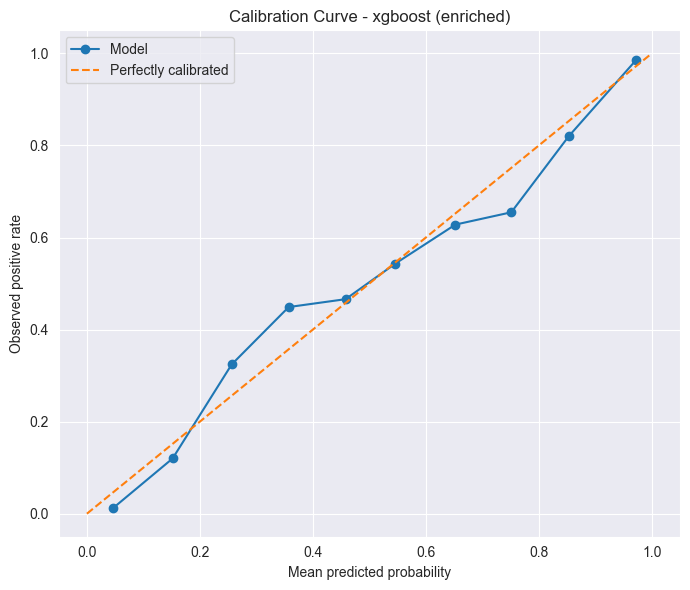

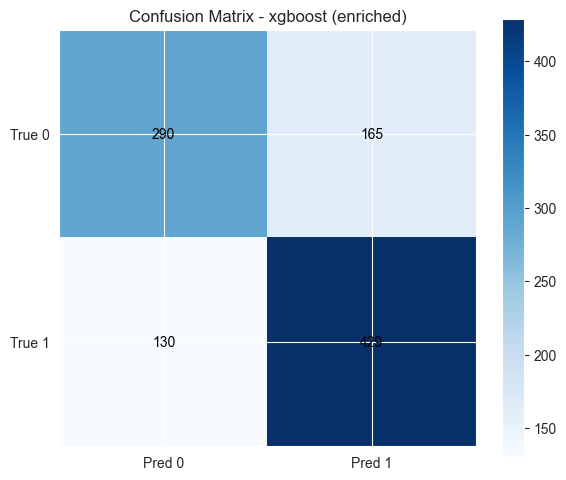

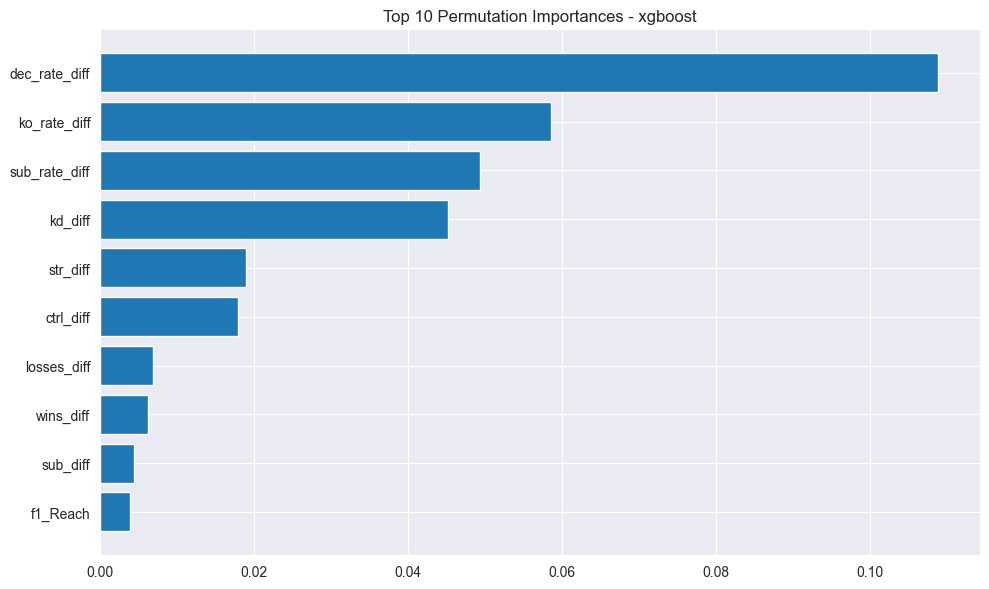


Modeling pipeline completed.
Saved comparison table to: C:\Users\Victus\Desktop\DSA210project\Fightiq-ufc-matchup-intelligence\reports\modeling\model_comparison.csv
Saved best model to: C:\Users\Victus\Desktop\DSA210project\Fightiq-ufc-matchup-intelligence\models\best_model.joblib
Saved metadata to: C:\Users\Victus\Desktop\DSA210project\Fightiq-ufc-matchup-intelligence\models\best_model_metadata.json


In [3]:


import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, brier_score_loss, confusion_matrix
)
from sklearn.calibration import calibration_curve
from sklearn.inspection import permutation_importance

try:
    from xgboost import XGBClassifier
    XGB_AVAILABLE = True
except Exception:
    XGB_AVAILABLE = False


ROOT = Path("..")
DATA_PATH = ROOT / "data" / "processed" / "model_base_table_clean_names.csv"
REPORT_DIR = ROOT / "reports" / "modeling"
FIG_DIR = ROOT / "figures" / "modeling"
MODEL_DIR = ROOT / "models"

REPORT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Could not find: {DATA_PATH.resolve()}")


df = pd.read_csv(DATA_PATH, low_memory=False)
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df = df.dropna(subset=["Date", "target"]).copy()
df["fight_year"] = df["Date"].dt.year

print("Loaded:", df.shape)
print("Date range:", df["Date"].min(), "to", df["Date"].max())


for col in ["f1_Height", "f2_Height", "f1_Weight", "f2_Weight", "f1_Reach", "f2_Reach"]:
    if col in df.columns:
        df[f"{col}_missing"] = df[col].isna().astype(int)


safe_numeric = [
    "height_diff", "weight_diff", "reach_diff",
    "f1_Height", "f2_Height",
    "f1_Weight", "f2_Weight",
    "f1_Reach", "f2_Reach",
    "fight_year",
    "f1_Height_missing", "f2_Height_missing",
    "f1_Weight_missing", "f2_Weight_missing",
    "f1_Reach_missing", "f2_Reach_missing",
]

safe_categorical = [
    "Weight_Class",
    "Time Format",
    "f1_Stance",
    "f2_Stance",
]

enriched_numeric_extra = [
    "wins_diff", "losses_diff", "draws_diff",
    "avg_fight_time_diff",
    "kd_diff", "str_diff", "td_diff", "sub_diff", "ctrl_diff",
    "sig_str_pct_diff", "sub_att_diff",
    "ko_rate_diff", "sub_rate_diff", "dec_rate_diff",
]

safe_numeric = [c for c in safe_numeric if c in df.columns]
safe_categorical = [c for c in safe_categorical if c in df.columns]
enriched_numeric_extra = [c for c in enriched_numeric_extra if c in df.columns]

feature_sets = {
    "safe": {
        "numeric": safe_numeric,
        "categorical": safe_categorical
    },
    "enriched": {
        "numeric": safe_numeric + enriched_numeric_extra,
        "categorical": safe_categorical
    }
}

TARGET = "target"


years = sorted(df["fight_year"].dropna().unique())
print("Years:", years)

if len(years) >= 6:
    train_years = years[:-4]
    val_years = years[-4:-2]
    test_years = years[-2:]
elif len(years) >= 4:
    train_years = years[:-2]
    val_years = [years[-2]]
    test_years = [years[-1]]
else:
    raise ValueError("Not enough distinct years for temporal split.")

train_df = df[df["fight_year"].isin(train_years)].copy()
val_df = df[df["fight_year"].isin(val_years)].copy()
test_df = df[df["fight_year"].isin(test_years)].copy()

print("Train shape:", train_df.shape, "years:", train_years)
print("Val shape:", val_df.shape, "years:", val_years)
print("Test shape:", test_df.shape, "years:", test_years)


def build_preprocessor(numeric_features, categorical_features, model_type="linear"):
    if model_type == "linear":
        numeric_pipe = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ])
    else:
        numeric_pipe = Pipeline([
            ("imputer", SimpleImputer(strategy="median"))
        ])

    categorical_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])

    preprocessor = ColumnTransformer([
        ("num", numeric_pipe, numeric_features),
        ("cat", categorical_pipe, categorical_features)
    ])

    return preprocessor


def build_models(numeric_features, categorical_features):
    models = {}

    # Logistic Regression
    models["logistic_regression"] = Pipeline([
        ("preprocess", build_preprocessor(numeric_features, categorical_features, model_type="linear")),
        ("model", LogisticRegression(max_iter=3000))
    ])

    # Random Forest
    models["random_forest"] = Pipeline([
        ("preprocess", build_preprocessor(numeric_features, categorical_features, model_type="tree")),
        ("model", RandomForestClassifier(
            n_estimators=400,
            max_depth=None,
            min_samples_split=5,
            min_samples_leaf=2,
            random_state=42,
            n_jobs=-1
        ))
    ])

    # XGBoost if available
    if XGB_AVAILABLE:
        models["xgboost"] = Pipeline([
            ("preprocess", build_preprocessor(numeric_features, categorical_features, model_type="tree")),
            ("model", XGBClassifier(
                n_estimators=400,
                max_depth=5,
                learning_rate=0.05,
                subsample=0.9,
                colsample_bytree=0.9,
                random_state=42,
                eval_metric="logloss"
            ))
        ])

    return models


def evaluate_model(model, X, y):
    pred = model.predict(X)
    if hasattr(model, "predict_proba"):
        prob = model.predict_proba(X)[:, 1]
    else:
        prob = pred.astype(float)

    return {
        "accuracy": accuracy_score(y, pred),
        "precision": precision_score(y, pred, zero_division=0),
        "recall": recall_score(y, pred, zero_division=0),
        "f1": f1_score(y, pred, zero_division=0),
        "roc_auc": roc_auc_score(y, prob),
        "brier": brier_score_loss(y, prob),
        "pred": pred,
        "prob": prob
    }

def plot_calibration_curve(y_true, y_prob, title, filename):
    prob_true, prob_pred = calibration_curve(y_true, y_prob, n_bins=10, strategy="uniform")
    fig, ax = plt.subplots(figsize=(7, 6))
    ax.plot(prob_pred, prob_true, marker="o", label="Model")
    ax.plot([0, 1], [0, 1], linestyle="--", label="Perfectly calibrated")
    ax.set_title(title)
    ax.set_xlabel("Mean predicted probability")
    ax.set_ylabel("Observed positive rate")
    ax.legend()
    fig.tight_layout()
    fig.savefig(FIG_DIR / filename, dpi=300, bbox_inches="tight")
    plt.show()

def save_confusion_matrix(y_true, y_pred, title, filename):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["Pred 0", "Pred 1"])
    ax.set_yticklabels(["True 0", "True 1"])
    ax.set_title(title)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha="center", va="center", color="black")
    fig.colorbar(im, ax=ax)
    fig.tight_layout()
    fig.savefig(FIG_DIR / filename, dpi=300, bbox_inches="tight")
    plt.show()


results = []
fitted_models = {}
best_model_name = None
best_feature_set = None
best_val_auc = -1

for feature_set_name, feature_spec in feature_sets.items():
    num_feats = feature_spec["numeric"]
    cat_feats = feature_spec["categorical"]
    all_feats = num_feats + cat_feats

    X_train = train_df[all_feats].copy()
    y_train = train_df[TARGET].copy()

    X_val = val_df[all_feats].copy()
    y_val = val_df[TARGET].copy()

    X_test = test_df[all_feats].copy()
    y_test = test_df[TARGET].copy()

    models = build_models(num_feats, cat_feats)

    for model_name, model in models.items():
        print(f"\nTraining {model_name} on {feature_set_name} features...")
        model.fit(X_train, y_train)

        val_metrics = evaluate_model(model, X_val, y_val)
        test_metrics = evaluate_model(model, X_test, y_test)

        results.append({
            "feature_set": feature_set_name,
            "model": model_name,
            "val_accuracy": val_metrics["accuracy"],
            "val_precision": val_metrics["precision"],
            "val_recall": val_metrics["recall"],
            "val_f1": val_metrics["f1"],
            "val_roc_auc": val_metrics["roc_auc"],
            "val_brier": val_metrics["brier"],
            "test_accuracy": test_metrics["accuracy"],
            "test_precision": test_metrics["precision"],
            "test_recall": test_metrics["recall"],
            "test_f1": test_metrics["f1"],
            "test_roc_auc": test_metrics["roc_auc"],
            "test_brier": test_metrics["brier"],
        })

        fitted_models[(feature_set_name, model_name)] = {
            "model": model,
            "features": all_feats,
            "numeric": num_feats,
            "categorical": cat_feats,
            "val_metrics": val_metrics,
            "test_metrics": test_metrics
        }

        if val_metrics["roc_auc"] > best_val_auc:
            best_val_auc = val_metrics["roc_auc"]
            best_model_name = model_name
            best_feature_set = feature_set_name

results_df = pd.DataFrame(results).sort_values(by="val_roc_auc", ascending=False)
results_df.to_csv(REPORT_DIR / "model_comparison.csv", index=False)

print("\nModel comparison:")
print(results_df)

print("\nBest model:", best_model_name)
print("Best feature set:", best_feature_set)
print("Best validation ROC-AUC:", round(best_val_auc, 4))


strength_map = {
    "logistic_regression": ("Interpretable, stable baseline", "May miss nonlinear relationships"),
    "random_forest": ("Captures nonlinear interactions", "Can be less calibrated, less interpretable"),
    "xgboost": ("Usually strongest tabular performance", "Harder to interpret, may overfit if unchecked"),
}

comparison_table = results_df.copy()
comparison_table["strength"] = comparison_table["model"].map(lambda x: strength_map.get(x, ("", ""))[0])
comparison_table["weakness"] = comparison_table["model"].map(lambda x: strength_map.get(x, ("", ""))[1])
comparison_table.to_csv(REPORT_DIR / "model_comparison_with_notes.csv", index=False)


best_bundle = fitted_models[(best_feature_set, best_model_name)]
best_model = best_bundle["model"]
best_features = best_bundle["features"]

X_test_best = test_df[best_features].copy()
y_test_best = test_df[TARGET].copy()
best_test = best_bundle["test_metrics"]

plot_calibration_curve(
    y_test_best,
    best_test["prob"],
    title=f"Calibration Curve - {best_model_name} ({best_feature_set})",
    filename="best_model_calibration_curve.png"
)

save_confusion_matrix(
    y_test_best,
    best_test["pred"],
    title=f"Confusion Matrix - {best_model_name} ({best_feature_set})",
    filename="best_model_confusion_matrix.png"
)


error_df = test_df.copy()
error_df["pred"] = best_test["pred"]
error_df["prob"] = best_test["prob"]
error_df["correct"] = (error_df["pred"] == error_df[TARGET]).astype(int)
error_df["confidence"] = np.where(error_df["pred"] == 1, error_df["prob"], 1 - error_df["prob"])

# high confidence wrong predictions
high_conf_wrong = error_df[error_df["correct"] == 0].copy().sort_values(by="confidence", ascending=False)
high_conf_wrong.to_csv(REPORT_DIR / "high_confidence_wrong_predictions.csv", index=False)

# wrong predictions by weight class
if "Weight_Class" in error_df.columns:
    error_by_weight = error_df.groupby("Weight_Class")["correct"].mean().reset_index()
    error_by_weight["error_rate"] = 1 - error_by_weight["correct"]
    error_by_weight = error_by_weight.sort_values(by="error_rate", ascending=False)
    error_by_weight.to_csv(REPORT_DIR / "error_rate_by_weight_class.csv", index=False)

# missing reach effect
if "f1_Reach_missing" in error_df.columns and "f2_Reach_missing" in error_df.columns:
    error_df["any_reach_missing"] = ((error_df["f1_Reach_missing"] == 1) | (error_df["f2_Reach_missing"] == 1)).astype(int)
    error_by_reach_missing = error_df.groupby("any_reach_missing")["correct"].mean().reset_index()
    error_by_reach_missing["error_rate"] = 1 - error_by_reach_missing["correct"]
    error_by_reach_missing.to_csv(REPORT_DIR / "error_rate_by_reach_missing.csv", index=False)


preprocessor = best_model.named_steps["preprocess"]
model_obj = best_model.named_steps["model"]

feature_names = preprocessor.get_feature_names_out()

# Logistic regression coefficients
if best_model_name == "logistic_regression":
    coefs = model_obj.coef_[0]
    coef_df = pd.DataFrame({
        "feature": feature_names,
        "coefficient": coefs,
        "abs_coefficient": np.abs(coefs)
    }).sort_values(by="abs_coefficient", ascending=False)

    coef_df.to_csv(REPORT_DIR / "logistic_coefficients.csv", index=False)

    top_coef = coef_df.head(10).iloc[::-1]
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(top_coef["feature"], top_coef["coefficient"])
    ax.set_title("Top 10 Logistic Regression Coefficients")
    fig.tight_layout()
    fig.savefig(FIG_DIR / "logistic_top_coefficients.png", dpi=300, bbox_inches="tight")
    plt.show()

# Permutation importance for best model
perm = permutation_importance(
    best_model,
    X_test_best,
    y_test_best,
    n_repeats=10,
    random_state=42,
    scoring="roc_auc"
)

perm_df = pd.DataFrame({
    "feature": best_features,
    "importance_mean": perm.importances_mean[:len(best_features)],
    "importance_std": perm.importances_std[:len(best_features)]
}).sort_values(by="importance_mean", ascending=False)

perm_df.to_csv(REPORT_DIR / "best_model_permutation_importance.csv", index=False)

top_perm = perm_df.head(10).iloc[::-1]
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_perm["feature"], top_perm["importance_mean"])
ax.set_title(f"Top 10 Permutation Importances - {best_model_name}")
fig.tight_layout()
fig.savefig(FIG_DIR / "best_model_permutation_importance.png", dpi=300, bbox_inches="tight")
plt.show()



train_reference = {}
for col in best_features:
    if col in train_df.columns:
        if pd.api.types.is_numeric_dtype(train_df[col]):
            train_reference[col] = train_df[col].median()
        else:
            mode_vals = train_df[col].mode(dropna=True)
            train_reference[col] = mode_vals.iloc[0] if len(mode_vals) > 0 else np.nan

def local_feature_impact(model, sample_row, reference_dict, feature_list):
    base_prob = model.predict_proba(sample_row[feature_list])[:, 1][0]
    impacts = []

    for col in feature_list:
        modified = sample_row[feature_list].copy()
        modified[col] = reference_dict.get(col, np.nan)
        new_prob = model.predict_proba(modified)[:, 1][0]
        impacts.append({
            "feature": col,
            "base_probability": base_prob,
            "new_probability": new_prob,
            "impact": base_prob - new_prob
        })

    return pd.DataFrame(impacts).sort_values(by="impact", key=np.abs, ascending=False)

# confident correct
conf_correct = error_df[error_df["correct"] == 1].sort_values(by="confidence", ascending=False).head(1)
if len(conf_correct) > 0:
    idx = conf_correct.index[0]
    sample = error_df.loc[[idx]].copy()
    local_correct = local_feature_impact(best_model, sample, train_reference, best_features)
    local_correct.to_csv(REPORT_DIR / "local_explanation_confident_correct.csv", index=False)

# confident wrong
conf_wrong = error_df[error_df["correct"] == 0].sort_values(by="confidence", ascending=False).head(1)
if len(conf_wrong) > 0:
    idx = conf_wrong.index[0]
    sample = error_df.loc[[idx]].copy()
    local_wrong = local_feature_impact(best_model, sample, train_reference, best_features)
    local_wrong.to_csv(REPORT_DIR / "local_explanation_confident_wrong.csv", index=False)


joblib.dump(best_model, MODEL_DIR / "best_model.joblib")

metadata = {
    "best_model_name": best_model_name,
    "best_feature_set": best_feature_set,
    "features": best_features,
    "numeric_features": best_bundle["numeric"],
    "categorical_features": best_bundle["categorical"],
    "train_years": train_years,
    "val_years": val_years,
    "test_years": test_years,
    "test_metrics": {
        "accuracy": float(best_test["accuracy"]),
        "precision": float(best_test["precision"]),
        "recall": float(best_test["recall"]),
        "f1": float(best_test["f1"]),
        "roc_auc": float(best_test["roc_auc"]),
        "brier": float(best_test["brier"])
    }
}
def json_converter(obj):
    import numpy as np
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.floating,)):
        return float(obj)
    if isinstance(obj, (np.ndarray,)):
        return obj.tolist()
    raise TypeError(f"Object of type {type(obj).__name__} is not JSON serializable")
with open(MODEL_DIR / "best_model_metadata.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2, default=json_converter)


notes = []
notes.append(f"Best model: {best_model_name}")
notes.append(f"Best feature set: {best_feature_set}")
notes.append(f"Train years: {train_years}")
notes.append(f"Validation years: {val_years}")
notes.append(f"Test years: {test_years}")
notes.append("Test metrics:")
for k, v in metadata["test_metrics"].items():
    notes.append(f"  - {k}: {v:.4f}")

notes.append("")
notes.append("Interpretation notes:")
notes.append("- Logistic Regression is the clean baseline.")
notes.append("- Random Forest captures nonlinear interactions.")
notes.append("- XGBoost is expected to be strongest on rich tabular data if available.")
notes.append("- The safe feature set is the main academically cleaner setup.")
notes.append("- The enriched feature set is exploratory and may contain more temporal-risk variables.")

with open(REPORT_DIR / "modeling_notes.txt", "w", encoding="utf-8") as f:
    for line in notes:
        f.write(line + "\n")

print("\nModeling pipeline completed.")
print("Saved comparison table to:", (REPORT_DIR / "model_comparison.csv").resolve())
print("Saved best model to:", (MODEL_DIR / "best_model.joblib").resolve())
print("Saved metadata to:", (MODEL_DIR / "best_model_metadata.json").resolve())